In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
device = torch.device('cuda')
# device = 'cpu'

In [3]:
words = open("names.txt", "r").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 8 #  context lengthL how many characters do we take to predict the next one

def build_dataset(words):
    X, Y = [], []
    for w in words:
        
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix= stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '---->', itos[ix])
            context = context[1:] + [ix] # crop and append
            
    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [6]:
class Linear:
    
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), device=device) / fan_in**0.5
        self.bias = torch.zeros((fan_out), device=device) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
    
class BatchNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters trained with backprop
        self.gamma = torch.ones((dim), device=device)
        self.beta = torch.zeros((dim), device=device)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros((dim), device=device)
        self.running_var = torch.ones((dim), device=device)
        
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            if x.ndim == 2:
                dim=0
            elif x.ndim ==3:
                dim = (0,1)
            xmean = x.mean(dim, keepdims=True)
            xvar = x.var(dim, keepdims=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        # update buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean + self.momentum * xmean
                self.running_var = (1-self.momentum)*self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim), device=device)
        
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
class FlattenConsecutive:
    def __init__(self, n):
        self.n = n
        
    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        
        self.out = x
        
        return self.out

    def parameters(self):
        return []
    

class Sequential:
    
    def __init__(self, layers):
        self.layers = layers
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [ p for layer in self.layers for p in layer.parameters()]
        

In [7]:
torch.manual_seed(42);

In [9]:
n_embed = 48
n_hidden = 256

model = Sequential([
    Embedding(vocab_size, n_embed),
    
    FlattenConsecutive(2),
    Linear(n_embed * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    
    FlattenConsecutive(2),
    Linear(n_hidden*2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1 # make last layers less confident
    
parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True
    

296491


In [129]:
x = torch.randint(0, vocab_size, (4,8), device=device)
for layer in model.layers:
    x = layer(x)
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 48)
FlattenConsecutive : (4, 4, 96)
Linear : (4, 4, 256)
BatchNorm1d : (4, 4, 256)
Tanh : (4, 4, 256)
FlattenConsecutive : (4, 2, 512)
Linear : (4, 2, 256)
BatchNorm1d : (4, 2, 256)
Tanh : (4, 2, 256)
FlattenConsecutive : (4, 512)
Linear : (4, 256)
BatchNorm1d : (4, 256)
Tanh : (4, 256)
Linear : (4, 27)


In [ ]:
# optimzation

max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), device=device)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y
    
    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb) # loss function
    
    # backward pass
    for p in parameters:
         p.grad=None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 1000 == 0:
        print(f"{i:7d}/ {max_steps:7d}: {loss.item():4f}")
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
    
    # break
    # if i >10000:
        # break

      0/  200000: 3.297004
   1000/  200000: 2.616181
   2000/  200000: 1.868128
   3000/  200000: 1.950169
   4000/  200000: 2.049958
   5000/  200000: 2.353295
   6000/  200000: 2.327865
   7000/  200000: 2.385080
   8000/  200000: 1.973456
   9000/  200000: 2.116410
  10000/  200000: 1.690966
  11000/  200000: 1.891039
  12000/  200000: 2.248840
  13000/  200000: 1.914119
  14000/  200000: 1.880955
  15000/  200000: 2.212913
  16000/  200000: 2.166301
  17000/  200000: 2.548095
  18000/  200000: 2.522779
  19000/  200000: 1.865211
  20000/  200000: 2.037282
  21000/  200000: 2.242434
  22000/  200000: 2.172076
  23000/  200000: 1.780175
  24000/  200000: 2.181393
  25000/  200000: 2.103661
  26000/  200000: 1.884439
  27000/  200000: 2.186684
  28000/  200000: 1.895224
  29000/  200000: 1.748051
  30000/  200000: 1.872987
  31000/  200000: 2.127951
  32000/  200000: 2.016266
  33000/  200000: 1.715142
  34000/  200000: 1.995223
  35000/  200000: 2.251401
  36000/  200000: 1.784045
 

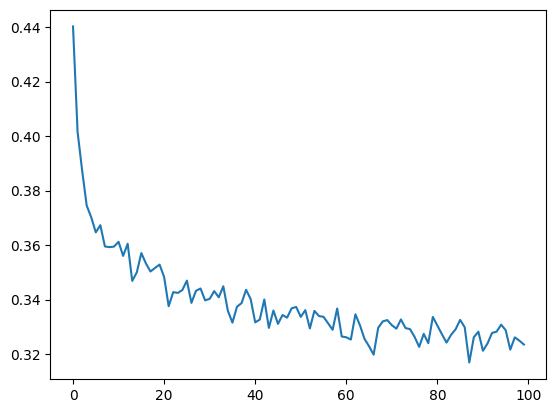

In [102]:
plt.plot(torch.tensor(lossi).view(-1, 100).mean(1))

In [103]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
    layer.training = False

In [104]:
# evaluate the loss
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1054983139038086
val 2.152384042739868


In [105]:
# sample from the model

for _ in range(20):

    out = []
    context = [0] * block_size

    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        
        # sample from the distribution
        ix  = torch.multinomial(probs, num_samples=1).item()
        
        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

kyaste.
reden.
yakielle.
kw.
vazia.
iranzel.
karayah.
ralsis.
lajaye.
avi.
keylan.
graylan.
samour.
railyn.
cerren.
karian.
akseida.
aaziyahi.
jalek.
emeresa.


In [21]:
context

[0, 0, 0]